In [1]:
!pip install yfinance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
!pip install yfinance

# Data Colection

In [2]:
now = datetime.now()
start= datetime(now.year-10,now.month,now.day)
end= now
ticker='AAPL'
df=yf.download(ticker,start,end)
df



C:\Users\ASUS\AppData\Local\Temp\ipykernel_3480\448876305.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,start,end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-11-03,27.544611,27.751358,27.124374,27.144600,182076000
2015-11-04,27.416525,27.825525,27.331130,27.670464,179544400
2015-11-05,27.290129,27.689596,27.123120,27.500018,158210800
2015-11-06,27.321724,27.490990,27.222423,27.333009,132169200
2015-11-09,27.211143,27.490996,27.093787,27.299161,135485600
...,...,...,...,...,...
2025-10-28,269.000000,269.890015,268.149994,268.989990,41534800
2025-10-29,269.700012,271.410004,267.109985,269.279999,51086700


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-11-03,27.544611,27.751358,27.124374,27.144600,182076000
2015-11-04,27.416525,27.825525,27.331130,27.670464,179544400
2015-11-05,27.290129,27.689596,27.123120,27.500018,158210800
2015-11-06,27.321724,27.490990,27.222423,27.333009,132169200
2015-11-09,27.211143,27.490996,27.093787,27.299161,135485600


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-10-28,269.000000,269.890015,268.149994,268.989990,41534800
2025-10-29,269.700012,271.410004,267.109985,269.279999,51086700
2025-10-30,271.399994,274.140015,268.480011,271.989990,69886500
2025-10-31,270.369995,277.320007,269.160004,276.989990,86096700
2025-11-03,267.670013,270.850006,267.670013,270.420013,5207785


# Data exploration and visualization

In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
df.shape

(2515, 5)

In [7]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,110.411954,111.511851,109.197536,110.308705,1.036306e+08
std,71.358956,72.045644,70.586108,71.287374,5.837418e+07
min,20.624050,20.927682,20.425436,20.546432,5.207785e+06
25%,40.851038,41.127530,40.564711,40.872410,6.382810e+07
50%,115.782600,117.443932,113.819202,116.008752,9.031800e+07
75%,169.672554,171.402468,168.417003,169.550837,1.270292e+08
max,271.399994,277.320007,269.160004,276.989990,5.334788e+08


In [9]:
df=df.reset_index()

In [10]:
df.head()
df.shape

(2515, 6)

Text(0, 0.5, 'close price')

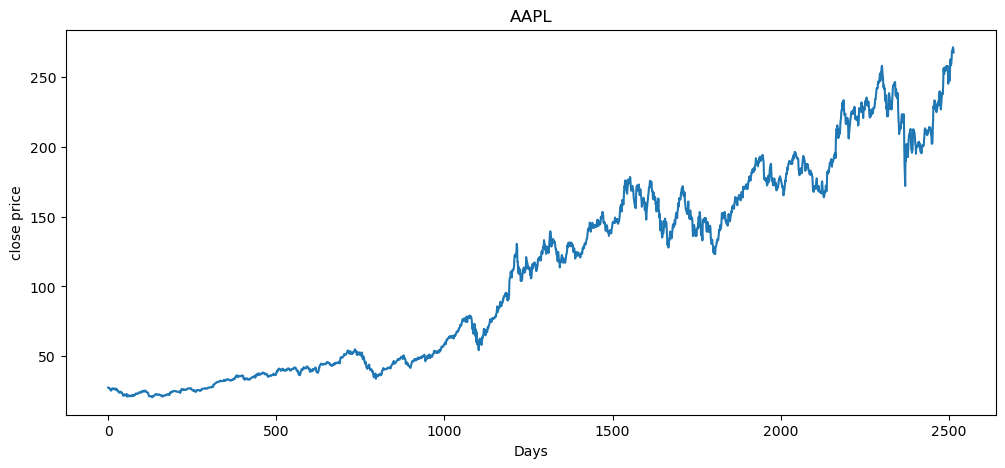

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('close price')

# Feature engineering

### moving average

In [12]:
df1=pd.DataFrame([10,20,30,40,50,60,70,80,90])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90


In [13]:
# now the moving average

df1['MA_5']= df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0


### 100 days Moving Average



In [14]:
df['MA_100']= df.Close.rolling(100).mean()
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2015-11-03,27.544611,27.751358,27.124374,27.144600,182076000,NaN
1,2015-11-04,27.416525,27.825525,27.331130,27.670464,179544400,NaN
2,2015-11-05,27.290129,27.689596,27.123120,27.500018,158210800,NaN
3,2015-11-06,27.321724,27.490990,27.222423,27.333009,132169200,NaN
4,2015-11-09,27.211143,27.490996,27.093787,27.299161,135485600,NaN
...,...,...,...,...,...,...,...
98,2016-03-28,23.868889,24.095801,23.839389,24.052687,77645600,NaN
99,2016-03-29,24.433893,24.458854,23.798539,23.800808,124760400,23.876657
100,2016-03-30,24.860491,25.055635,24.642655,24.654002,182404400,23.849816


Text(0, 0.5, 'close price')

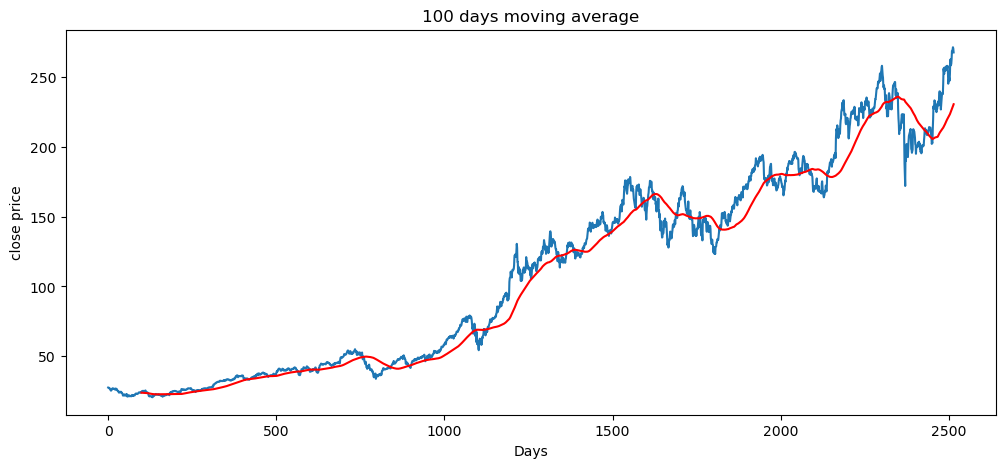

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'],'r')
plt.title('100 days moving average')
plt.xlabel('Days')
plt.ylabel('close price')


#### 200 days moving average

In [16]:
df['MA_200']= df.Close.rolling(200).mean()
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2015-11-03,27.544611,27.751358,27.124374,27.144600,182076000,NaN,NaN
1,2015-11-04,27.416525,27.825525,27.331130,27.670464,179544400,NaN,NaN
2,2015-11-05,27.290129,27.689596,27.123120,27.500018,158210800,NaN,NaN
3,2015-11-06,27.321724,27.490990,27.222423,27.333009,132169200,NaN,NaN
4,2015-11-09,27.211143,27.490996,27.093787,27.299161,135485600,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2016-08-17,25.069313,25.103743,24.867325,25.041769,101424000,22.935967,NaN
199,2016-08-18,25.037172,25.156527,25.023399,25.071602,87938800,22.942000,23.409329
200,2016-08-19,25.101448,25.177194,24.871918,24.966024,101472400,22.944410,23.397113


Text(0, 0.5, 'close price')

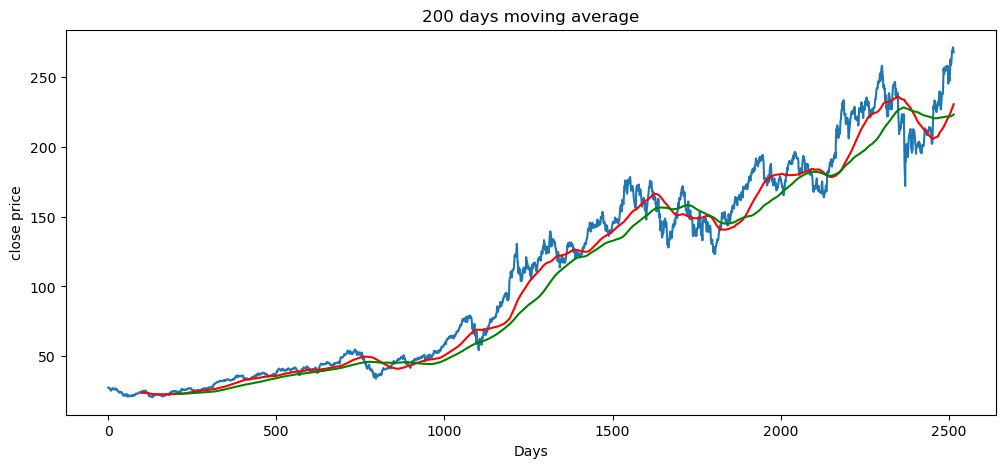

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'],'r')
plt.plot(df['MA_200'],'g')
plt.title('200 days moving average')
plt.xlabel('Days')
plt.ylabel('close price')

#### Percentage Change in each trading session

In [18]:
df['Percentage Change']= df.Close.pct_change()
df[['Close','Percentage Change']]

Price,Close,Percentage Change
Ticker,AAPL,
0,27.544611,NaN
1,27.416525,-0.004650
2,27.290129,-0.004610
3,27.321724,0.001158
4,27.211143,-0.004047
...,...,...
2510,269.000000,0.000707
2511,269.700012,0.002602
2512,271.399994,0.006303


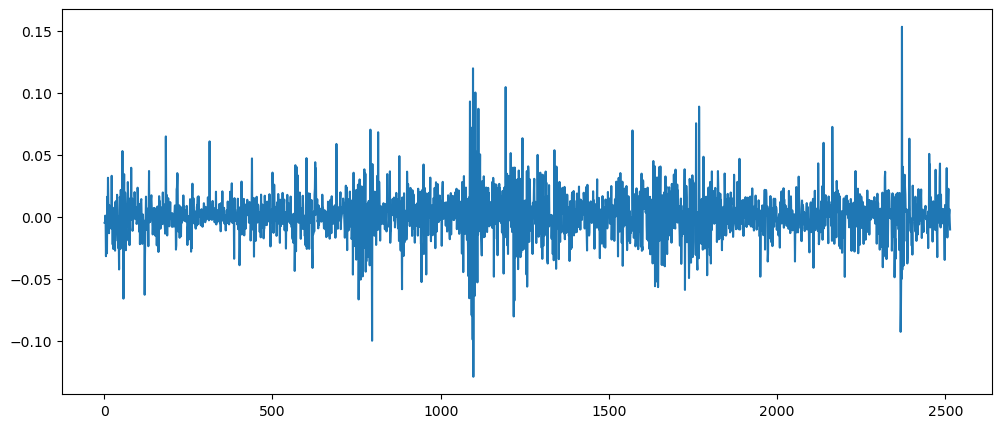

In [19]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Change'])

# Data Preprocessing

In [20]:
df.shape

(2515, 9)

## Spliting data into traning amd testing datasets

In [21]:
data_traning=pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing=pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])
print (data_traning)
print(data_testing)

Ticker        AAPL
0        27.544611
1        27.416525
2        27.290129
3        27.321724
4        27.211143
...            ...
1755    147.127518
1756    149.972626
1757    147.029068
1758    142.549789
1759    153.319778

[1760 rows x 1 columns]
Ticker        AAPL
1760    150.957062
1761    148.308868
1762    142.776199
1763    136.721802
1764    136.455536
...            ...
2510    269.000000
2511    269.700012
2512    271.399994
2513    270.369995
2514    267.670013

[755 rows x 1 columns]


### Scaling down the data between 0 and 1

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [23]:
data_traning_array= scaler.fit_transform(data_traning)
data_traning_array

array([[0.04385123],
       [0.04303963],
       [0.04223874],
       ...,
       [0.80094889],
       [0.77256653],
       [0.84080916]], shape=(1760, 1))

# Sequence Creation

In [24]:
x_train=[]
y_train=[]
for i in range(100,data_traning_array.shape[0]):
    x_train.append(data_traning_array[i-100:i])
    y_train.append(data_traning_array[i,0])
    

In [25]:
x_train, y_train= np.array(x_train),np.array(y_train)

In [26]:
x_train

array([[[0.04385123],
        [0.04303963],
        [0.04223874],
        ...,
        [0.02125062],
        [0.0205605 ],
        [0.02414057]],

       [[0.04303963],
        [0.04223874],
        [0.04243894],
        ...,
        [0.0205605 ],
        [0.02414057],
        [0.02684365]],

       [[0.04223874],
        [0.04243894],
        [0.04173826],
        ...,
        [0.02414057],
        [0.02684365],
        [0.02602412]],

       ...,

       [[0.77492672],
        [0.77966082],
        [0.79566988],
        ...,
        [0.78797421],
        [0.80157271],
        [0.81960036]],

       [[0.77966082],
        [0.79566988],
        [0.79099794],
        ...,
        [0.80157271],
        [0.81960036],
        [0.80094889]],

       [[0.79566988],
        [0.79099794],
        [0.75785847],
        ...,
        [0.81960036],
        [0.80094889],
        [0.77256653]]], shape=(1660, 100, 1))

In [27]:
y_train

array([0.02684365, 0.02602412, 0.02746194, ..., 0.80094889, 0.77256653,
       0.84080916], shape=(1660,))

# Building machine lerning model using tenser flow

In [28]:
!pip install tensorflow

In [29]:
import tensorflow as tf

In [30]:
print(tf.__version__)

2.20.0


In [31]:
from keras.models import Sequential
from keras.layers import Dense,LSTM,Input

In [32]:
model=Sequential()
model.add(Input(shape=(100,1)))
model.add(LSTM(units=128,activation='tanh',return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# Model Training

In [33]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.0083
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 5.8470e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 5.6110e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 6.6386e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 6.3430e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 5.2392e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 4.7502e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.6577e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 4.9788e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.1163e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 4.1003e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 3.7405e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 3.6616e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 3.4468e-04
Epoch 15/50
52/52 ━

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

## Save the trained model 

In [35]:
model.save('Stock_prediction_model.keras')

# Prepring the testdata 

In [36]:
past_100_data=data_traning.tail(100)

In [37]:
final_df=pd.concat([past_100_data,data_testing],ignore_index=True)

In [38]:
final_df

Ticker,AAPL
0,145.458618
1,140.228577
2,134.811737
3,129.650482
4,130.515594
...,...
850,269.000000
851,269.700012
852,271.399994
853,270.369995


In [39]:
data_testing

Ticker,AAPL
1760,150.957062
1761,148.308868
1762,142.776199
1763,136.721802
1764,136.455536
...,...
2510,269.000000
2511,269.700012
2512,271.399994
2513,270.369995


In [40]:
input_data=scaler.fit_transform(final_df)
input_data

array([[1.49726427e-01],
       [1.14416617e-01],
       [7.78456685e-02],
       [4.30002604e-02],
       [4.88409313e-02],
       [6.65623857e-02],
       [3.09204990e-02],
       [4.08765580e-02],
       [6.94827211e-02],
       [6.60313313e-02],
       [8.54119828e-02],
       [1.07912205e-01],
       [1.07912205e-01],
       [7.99031307e-02],
       [9.17837081e-02],
       [7.51242595e-02],
       [8.97924860e-02],
       [1.07248259e-01],
       [1.16274947e-01],
       [1.39040645e-01],
       [1.43620281e-01],
       [1.29217324e-01],
       [1.35788491e-01],
       [1.33332866e-01],
       [1.53111680e-01],
       [1.64394551e-01],
       [1.43819413e-01],
       [1.69903815e-01],
       [1.83443383e-01],
       [1.98775454e-01],
       [1.90412609e-01],
       [1.82846192e-01],
       [1.73885950e-01],
       [2.08332990e-01],
       [2.12049752e-01],
       [2.46297763e-01],
       [2.39660665e-01],
       [2.29704967e-01],
       [2.70324908e-01],
       [2.68200485e-01],


In [41]:
input_data.shape

(855, 1)

In [42]:
x_text=[]
y_test=[]
for i in range(100,input_data.shape[0]):
    x_text.append(input_data[i-100:i])
    y_test.append(input_data[i,0])
    

In [43]:
x_text,y_test=np.array(x_text),np.array(y_test)

# Making Prediction

In [44]:
y_predicted=model.predict(x_text)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


### Now coverting back to compair the data

In [45]:
y_predicted=scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test=scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [52]:
y_predicted

array([147.71838 , 149.31079 , 148.92581 , 146.03368 , 141.52895 ,
       138.53087 , 137.2578  , 137.0966  , 135.63431 , 138.7169  ,
       142.86404 , 145.1159  , 146.64194 , 146.7856  , 147.275   ,
       147.82742 , 146.82072 , 146.81415 , 147.40202 , 146.70268 ,
       144.52516 , 141.81726 , 142.75554 , 144.24304 , 145.09187 ,
       144.98679 , 143.2466  , 141.10536 , 140.36736 , 140.04254 ,
       140.8217  , 141.9268  , 141.80959 , 138.9514  , 135.91411 ,
       133.25746 , 131.6582  , 131.95016 , 131.5391  , 130.97742 ,
       129.961   , 127.88663 , 127.36533 , 127.51286 , 126.25057 ,
       125.42396 , 124.5659  , 125.37501 , 126.55485 , 127.623825,
       129.18251 , 130.30702 , 131.354   , 132.39635 , 132.80469 ,
       132.91798 , 133.81653 , 135.74443 , 137.75897 , 138.80164 ,
       139.9893  , 141.49501 , 141.36606 , 141.4149  , 141.92824 ,
       144.46346 , 147.9609  , 149.10387 , 150.45363 , 150.0902  ,
       149.09627 , 148.57283 , 149.58018 , 150.23149 , 151.467

In [51]:
y_test

array([150.95706177, 148.30886841, 142.77619934, 136.72180176,
       136.45553589, 136.98803711, 137.55996704, 132.99435425,
       144.82748413, 147.61811829, 146.21786499, 147.9533844 ,
       146.72077942, 148.62393188, 149.18598938, 145.95162964,
       148.09146118, 148.96905518, 146.05024719, 142.21432495,
       139.20675659, 145.97135925, 146.24745178, 145.75440979,
       144.59082031, 140.92256165, 138.97993469, 140.66618347,
       140.18299866, 142.48057556, 143.44697571, 141.21838379,
       134.60169983, 132.63934326, 130.52912903, 130.46009827,
       133.56626892, 130.3910675 , 130.0262146 , 128.22167969,
       124.28716278, 127.80751801, 128.12304688, 123.3306427 ,
       124.60269928, 123.28134155, 127.81736755, 128.33996582,
       128.91194153, 131.63354492, 131.55467224, 132.885849  ,
       134.04949951, 133.32962036, 133.38879395, 135.95265198,
       139.14758301, 140.54782104, 139.88713074, 141.95793152,
       143.90052795, 141.0112915 , 142.28335571, 143.40

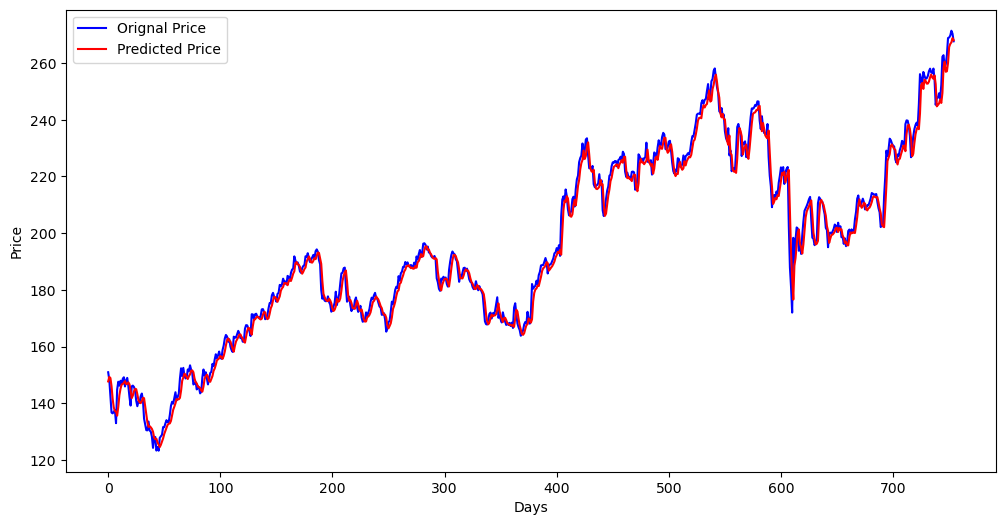

In [56]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Orignal Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(140.0, 220.0)

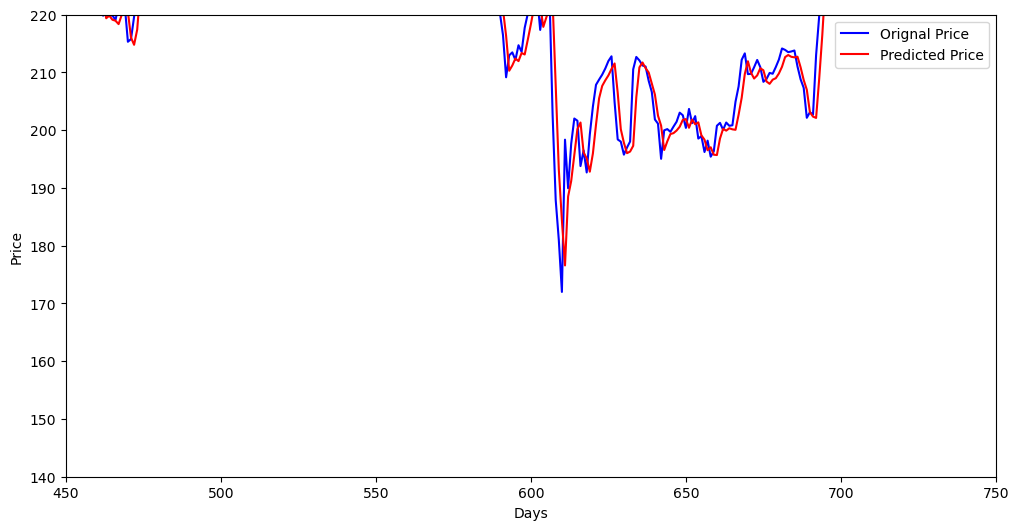

In [55]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Orignal Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450,750)
plt.ylim(140,220)

# Model Evaluation

In [62]:
from sklearn.metrics import mean_squared_error,r2_score


In [59]:
mse=mean_squared_error(y_test,y_predicted)
print(f'Mean Squared error(MSE): {mse}')

Mean Squared error(MSE): 14.01917929721716


### Root mean squared error

In [60]:
rmse=np.sqrt(mse)
print(f' Root Mean Squared error(RMSE): {rmse}')

 Root Mean Squared error(RMSE): 3.7442194509960496


### R-Squared

In [63]:
r2=r2_score(y_test,y_predicted)
print(f'R-Squared : {r2}')

R-Squared : 0.9870145390216541
